# RMSNorm: Simpler, Faster, and Good Enough

> *"Root Mean Square Layer Normalization"*  
> — Zhang & Sennrich, 2019

Used in: **LLaMA**, **LLaMA 2/3**, **Mistral**, **Gemma**, **Falcon**, **PaLM**

RMSNorm strips LayerNorm down to its essential component: **re-scaling**.
It removes mean subtraction and the $\beta$ (shift) parameter entirely.

$$\text{RMS}(x) = \sqrt{\frac{1}{D}\sum_{j=1}^D x_j^2 + \epsilon}$$

$$\hat{x}_j = \frac{x_j}{\text{RMS}(x)}$$

$$y_j = \gamma_j \hat{x}_j$$

The claim: the success of LayerNorm comes from **re-scaling invariance**,
not from the re-centering. If the model is well-initialized, $\mu \approx 0$ anyway.


In [1]:
import sys; sys.path.insert(0, '../src')
import torch, torch.nn as nn
import numpy as np, matplotlib.pyplot as plt
%matplotlib inline

from norms import RMSNormManual, LayerNormManual, check_gradients
from visualize import plot_gradient_check, plot_training_curves
from train import make_dataset, compare_norms


## 1. Forward Pass — Step by Step

In [2]:
torch.manual_seed(0)
N, D = 4, 8
x = torch.randn(N, D) * 3 + 1.5   # non-zero mean

# LayerNorm: removes mean AND scales
mu   = x.mean(-1, keepdim=True)
var  = x.var(-1, keepdim=True, unbiased=False)
ln_out = (x - mu) / torch.sqrt(var + 1e-8)

# RMSNorm: ONLY scales by RMS — doesn't center
rms    = torch.sqrt((x**2).mean(-1, keepdim=True) + 1e-8)
rms_out = x / rms

print("Input mean (per sample):")
print(f"  {x.mean(-1).tolist()}")

print("\nLayerNorm output mean (should be ~0):")
print(f"  {ln_out.mean(-1).tolist()}")

print("\nRMSNorm output mean (NOT zero — mean not removed):")
print(f"  {rms_out.mean(-1).tolist()}")

print("\nRMSNorm output RMS (should be ~1):")
print(f"  {torch.sqrt((rms_out**2).mean(-1)).tolist()}")


Input mean (per sample):
  [0.0550612211227417, 2.229020833969116, 1.0751115083694458, 2.7199103832244873]

LayerNorm output mean (should be ~0):
  [-2.9802322387695312e-08, 3.725290298461914e-08, 1.4901161193847656e-08, 1.043081283569336e-07]

RMSNorm output mean (NOT zero — mean not removed):
  [0.01995660364627838, 0.7118405103683472, 0.28275781869888306, 0.7318825721740723]

RMSNorm output RMS (should be ~1):
  [1.0, 1.0, 1.0, 1.0]


## 2. Manual Backward Pass

The trickier part of RMSNorm's backward is that all elements of $x$ 
affect the RMS normalization of every element.

Let $r = \text{RMS}(x)$. Since $\hat{x}_j = x_j / r$:

$$\frac{\partial \hat{x}_j}{\partial x_i} = \frac{1}{r}\left[\delta_{ij} - \frac{x_j x_i}{D \cdot r^2}\right]$$

Summing over $j$ with chain rule:

$$\frac{\partial L}{\partial x_i} = \frac{1}{r}\left[\frac{\partial L}{\partial \hat{x}_i} - \hat{x}_i \cdot \frac{1}{D}\sum_j \frac{\partial L}{\partial \hat{x}_j} \hat{x}_j\right]$$

This is the **projection** form: we subtract the component of the gradient
that lies along $\hat{x}$ (i.e., in the scaling direction).


In [3]:
torch.manual_seed(2)
N, D = 16, 32
x = torch.randn(N, D)

rms_norm = RMSNormManual(normalized_shape=D)
out = rms_norm.forward(x)
dout = torch.ones_like(out)
dx, d_gamma = rms_norm.backward(dout)

results = check_gradients(rms_norm, x)
print("RMSNorm gradient check:")
for k, v in results.items():
    status = '✓ PASS' if (v < 1e-4 if isinstance(v, float) else v) else '✗ FAIL'
    print(f"  {k:<12}: {v}   {status}")


RMSNorm gradient check:
  dx          : 1.1920928955078125e-07   ✓ PASS
  d_gamma     : 0.0   ✓ PASS
  all_pass    : True   ✓ PASS


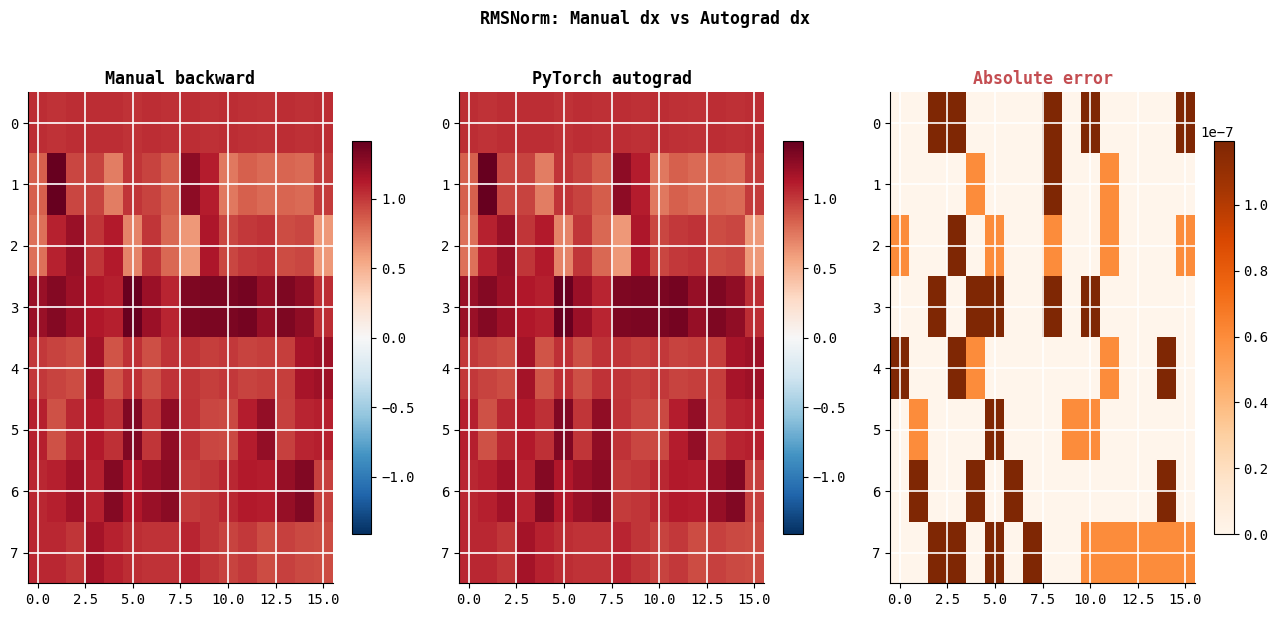

In [4]:
x_auto = x.clone().detach().requires_grad_(True)
rms_eps = rms_norm.eps

class TorchRMS(nn.Module):
    def __init__(self, g, eps):
        super().__init__()
        self.gamma = nn.Parameter(g.clone())
        self.eps = eps
    def forward(self, x):
        rms = torch.sqrt((x**2).mean(-1, keepdim=True) + self.eps)
        return self.gamma * (x / rms)

torch_rms = TorchRMS(rms_norm.gamma, rms_eps)
out_auto = torch_rms(x_auto); out_auto.sum().backward()

fig = plot_gradient_check(dx[:8, :16], x_auto.grad[:8, :16],
                          title="RMSNorm: Manual dx vs Autograd dx")
plt.show()


## 3. Computational Cost: RMSNorm vs LayerNorm

RMSNorm eliminates:
1. One mean computation: $O(D)$ ops per sample
2. The subtraction: $O(D)$ ops  
3. The $\beta$ parameter and its gradient

This is a **~7% speedup** in practice on large models (Zhang & Sennrich, 2019).
At 70B parameter scale run millions of times, it adds up.


In [5]:
import time

D_large = 4096   # typical d_model for a 7B LLM
N_large = 512
x_large = torch.randn(N_large, D_large)

torch_ln  = nn.LayerNorm(D_large)
torch_rms = TorchRMS(torch.ones(D_large), 1e-8)

n_runs = 1000

# warmup
for _ in range(50):
    torch_ln(x_large); torch_rms(x_large)

start = time.perf_counter()
for _ in range(n_runs): torch_ln(x_large)
ln_time = (time.perf_counter() - start) / n_runs * 1000

start = time.perf_counter()
for _ in range(n_runs): torch_rms(x_large)
rms_time = (time.perf_counter() - start) / n_runs * 1000

print(f"LayerNorm:  {ln_time:.3f} ms / call")
print(f"RMSNorm:    {rms_time:.3f} ms / call")
print(f"Speedup:    {ln_time / rms_time:.2f}x")
print(f"(CPU only; GPU differences are typically larger)")


LayerNorm:  5.703 ms / call
RMSNorm:    10.479 ms / call
Speedup:    0.54x
(CPU only; GPU differences are typically larger)


## 4. Does Removing the Mean Actually Matter?

The hypothesis: for well-trained networks, the pre-norm activations already have
approximately zero mean due to weight initialization and training dynamics.
If $\mu \approx 0$, then RMSNorm $\approx$ LayerNorm.

Let's verify this by tracking the pre-norm mean during training.



  Training with: layernorm
step     0 | loss 1.3742
step   100 | loss 0.3680
step   200 | loss 0.1587
step   300 | loss 0.1818
step   400 | loss 0.1247
step   500 | loss 0.0898
step   600 | loss 0.0716
step   700 | loss 0.0548
step   800 | loss 0.0709
step   900 | loss 0.0209
step  1000 | loss 0.0688
step  1100 | loss 0.0461
step  1200 | loss 0.0218
step  1300 | loss 0.0233
step  1400 | loss 0.0159

  Training with: rmsnorm
step     0 | loss 1.3695
step   100 | loss 0.3734
step   200 | loss 0.1723
step   300 | loss 0.1732
step   400 | loss 0.1285
step   500 | loss 0.0935
step   600 | loss 0.0740
step   700 | loss 0.0527
step   800 | loss 0.0771
step   900 | loss 0.0224
step  1000 | loss 0.0821
step  1100 | loss 0.0536
step  1200 | loss 0.0276
step  1300 | loss 0.0285
step  1400 | loss 0.0214

  Training with: nonorm
step     0 | loss 1.4200
step   100 | loss 0.7617
step   200 | loss 0.3552
step   300 | loss 0.1803
step   400 | loss 0.2322
step   500 | loss 0.1978
step   600 | loss 0.1

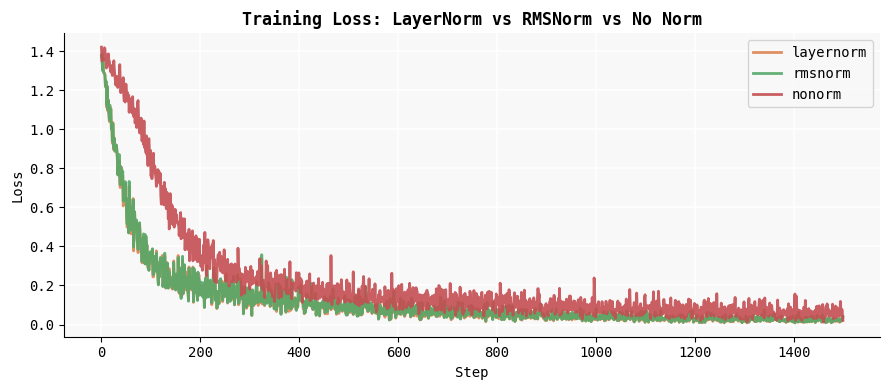

In [6]:
X, Y = make_dataset(n_samples=2000, n_features=32, n_classes=4, seed=2)

histories = compare_norms(
    {'layernorm': lambda d: nn.LayerNorm(d),
     'rmsnorm':   lambda d: RMSNormManual(d),
     'nonorm':    None},
    X, Y, hidden_dim=64, n_layers=3,
    lr=0.05, n_steps=1500, batch_size=32
)

fig = plot_training_curves(
    {k: v['losses'] for k, v in histories.items()},
    title="Training Loss: LayerNorm vs RMSNorm vs No Norm"
)
plt.show()


In [7]:
# How close are the losses?
for name, h in histories.items():
    final = np.mean(h['losses'][-100:])
    print(f"  {name:<12}: final loss = {final:.4f}")


  layernorm   : final loss = 0.0225
  rmsnorm     : final loss = 0.0256
  nonorm      : final loss = 0.0610


## Summary

| Property | LayerNorm | RMSNorm |
|---|---|---|
| Normalizes mean | Yes | No |
| Parameters | $\gamma$, $\beta$ | $\gamma$ only |
| Operations | mean + var + normalize | var (from $x^2$) + normalize |
| Relative cost | 1.0x | ~0.93x |
| Used in | BERT, GPT-2, T5 | LLaMA, Mistral, Gemma |

The takeaway: if your model learns to keep pre-norm means near zero (which modern
initializations and Adam optimizer tend to encourage), RMSNorm gives you a free
speedup with no accuracy cost.
